In [49]:
import time
import matplotlib.pyplot as plt
import numpy as np
import os

def medir_tiempo(funcion, n_ejecuciones, max_valor):
    tiempos = []
    for _ in range(n_ejecuciones):
        t0 = time.time()
        funcion(max_valor)
        t1 = time.time()
        tiempos.append(t1 - t0)
    return np.mean(tiempos)

# Algoritmos de ejemplo (reemplazar con tus funciones reales)
def algoritmo1(n):
    sumas = {}
    
    # Calcular sumas de divisores usando el metodo de la criba
    for i in range(1, n):
        for j in range(i * 2, n + 1, i):
            sumas[j] = sumas.get(j, 0) + i
    
    # Buscar pares de numeros amigos
    for i in range(n):
        s = sumas.get(i, 0)
        if s > i:
            continue
        else:
            if s in sumas:
                s2 = sumas[s]
    return sumas
import math

def suma_de_divisores(numero):
    if numero <= 1:
        return 0
    suma = 1  # 1 siempre es divisor
    sqrt_n = int(math.sqrt(numero))
    
    for i in range(2, sqrt_n + 1):
        if numero % i == 0:
            suma += i
            if i != numero // i:  # Evitar contar dos veces el mismo divisor
                suma += numero // i
    
    return suma

def algoritmo2(n):
    """Algoritmo de búsqueda de divisores para encontrar números amigos"""
    amigos = []
    sumas = [0] * n
    for i in range(n):
        sumas[i] = suma_de_divisores(i)
    for i in range(n):
        s = sumas[i]
        if s > i:
            continue
        else:
            s2 = sumas[s]
            if i == s2:
                amigos.append((i, s))
    return amigos

# Crear directorio para guardar gráficos
os.makedirs('graficos', exist_ok=True)

# Lista de valores a probar
intervalos = [1000, 2500, 5000, 7500, 10000, 150000, 200000, 250000]
n_ejecuciones = 3

In [50]:
print(f"Midiendo tiempos para diferentes valores de n...")

# Medir tiempos para cada valor en intervalos
tiempos_criba = []
tiempos_raiz = []

for n in intervalos:
    print(f"\nProbando con n = {n}:")
    tiempo_criba = medir_tiempo(algoritmo1, n_ejecuciones, n)
    tiempo_raiz = medir_tiempo(algoritmo2, n_ejecuciones, n)
    
    tiempos_criba.append(tiempo_criba)
    tiempos_raiz.append(tiempo_raiz)
    
    print(f"  Criba: {tiempo_criba:.4f} segundos")
    print(f"  Búsqueda de Divisores: {tiempo_raiz:.4f} segundos")

Midiendo tiempos para diferentes valores de n...

Probando con n = 1000:
  Criba: 0.0012 segundos
  Búsqueda de Divisores: 0.0021 segundos

Probando con n = 2500:
  Criba: 0.0044 segundos
  Búsqueda de Divisores: 0.0109 segundos

Probando con n = 5000:
  Criba: 0.0112 segundos
  Búsqueda de Divisores: 0.0172 segundos

Probando con n = 7500:
  Criba: 0.0093 segundos
  Búsqueda de Divisores: 0.0195 segundos

Probando con n = 10000:
  Criba: 0.0130 segundos
  Búsqueda de Divisores: 0.0295 segundos

Probando con n = 150000:
  Criba: 0.3429 segundos
  Búsqueda de Divisores: 1.4385 segundos

Probando con n = 200000:
  Criba: 0.5264 segundos
  Búsqueda de Divisores: 2.2849 segundos

Probando con n = 250000:
  Criba: 0.6953 segundos
  Búsqueda de Divisores: 3.2734 segundos


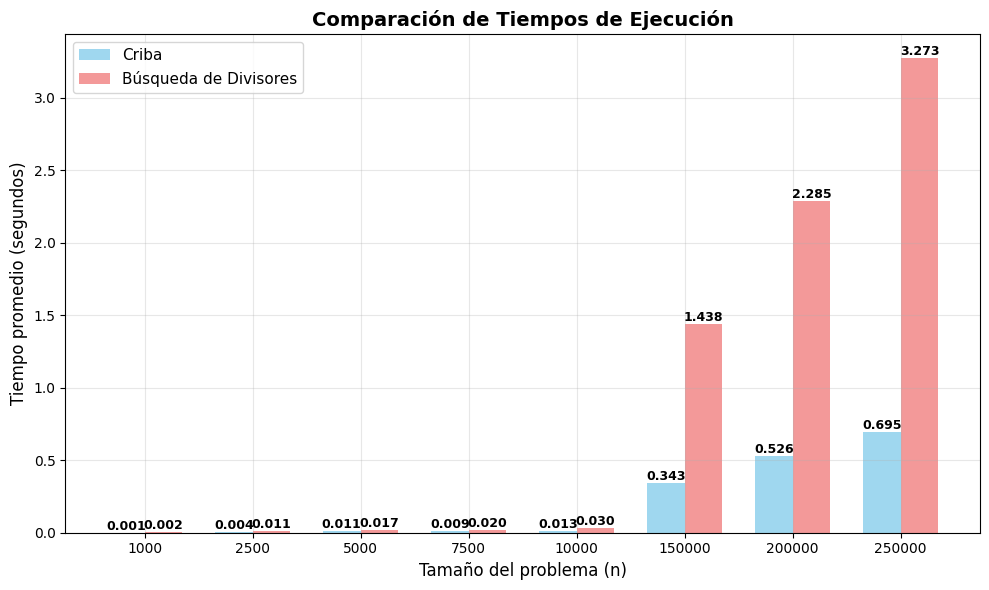

✓ Gráfico 1 guardado: graficos/01_comparacion_barras.png


In [51]:
# GRÁFICO 1: Comparación de barras
plt.figure(figsize=(10, 6))
x = np.arange(len(intervalos))
width = 0.35

bars1 = plt.bar(x - width/2, tiempos_criba, width, label='Criba', color='skyblue', alpha=0.8)
bars2 = plt.bar(x + width/2, tiempos_raiz, width, label='Búsqueda de Divisores', color='lightcoral', alpha=0.8)

plt.xlabel('Tamaño del problema (n)', fontsize=12)
plt.ylabel('Tiempo promedio (segundos)', fontsize=12)
plt.title('Comparación de Tiempos de Ejecución', fontsize=14, fontweight='bold')
plt.xticks(x, intervalos)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Añadir etiquetas de valor
for i, (tc, tr) in enumerate(zip(tiempos_criba, tiempos_raiz)):
    plt.text(i - width/2, tc, f'{tc:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    plt.text(i + width/2, tr, f'{tr:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('graficos/01_comparacion_barras.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Gráfico 1 guardado: graficos/01_comparacion_barras.png")

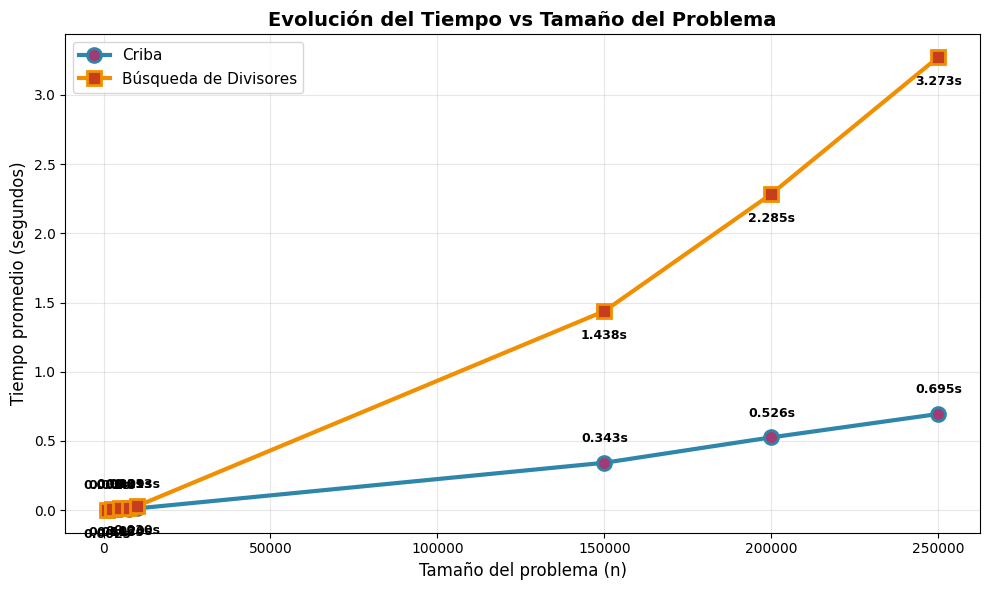

✓ Gráfico 2 guardado: graficos/02_evolucion_lineas.png


In [52]:
# GRÁFICO 2: Líneas de evolución
plt.figure(figsize=(10, 6))
plt.plot(intervalos, tiempos_criba, 'o-', label='Criba', linewidth=3, markersize=10, 
         color='#2E86AB', markerfacecolor='#A23B72', markeredgewidth=2)
plt.plot(intervalos, tiempos_raiz, 's-', label='Búsqueda de Divisores', linewidth=3, markersize=10,
         color='#F18F01', markerfacecolor='#C73E1D', markeredgewidth=2)

plt.xlabel('Tamaño del problema (n)', fontsize=12)
plt.ylabel('Tiempo promedio (segundos)', fontsize=12)
plt.title('Evolución del Tiempo vs Tamaño del Problema', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Añadir anotaciones
for i, (x, y) in enumerate(zip(intervalos, tiempos_criba)):
    plt.annotate(f'{y:.3f}s', (x, y), textcoords="offset points", 
                xytext=(0,15), ha='center', fontsize=9, fontweight='bold')

for i, (x, y) in enumerate(zip(intervalos, tiempos_raiz)):
    plt.annotate(f'{y:.3f}s', (x, y), textcoords="offset points", 
                xytext=(0,-20), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('graficos/02_evolucion_lineas.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Gráfico 2 guardado: graficos/02_evolucion_lineas.png")

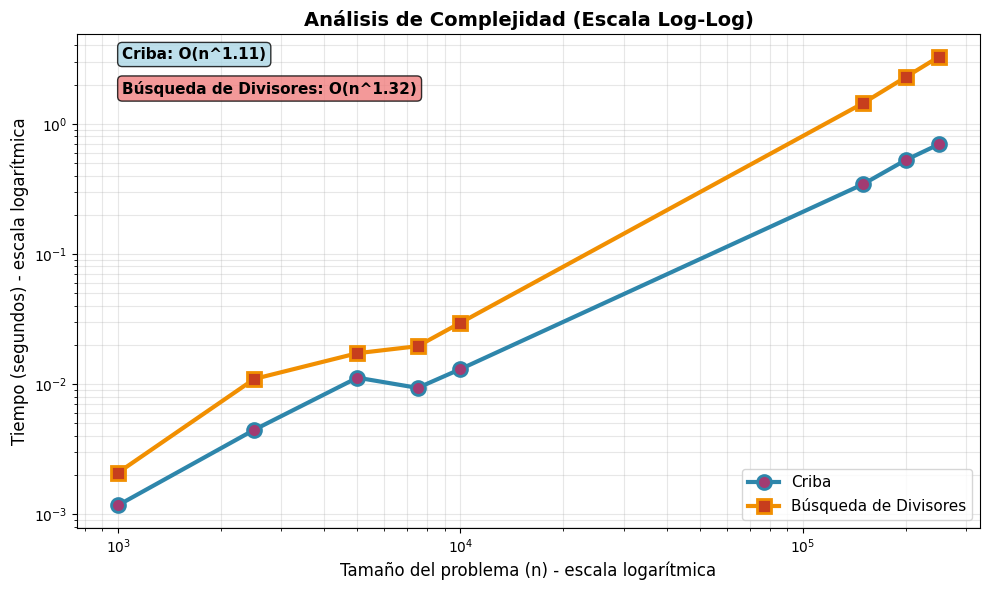

✓ Gráfico 3 guardado: graficos/03_analisis_complejidad.png


In [53]:
# GRÁFICO 3: Escala logarítmica para complejidad
plt.figure(figsize=(10, 6))
plt.loglog(intervalos, tiempos_criba, 'o-', label='Criba', linewidth=3, markersize=10,
           color='#2E86AB', markerfacecolor='#A23B72', markeredgewidth=2)
plt.loglog(intervalos, tiempos_raiz, 's-', label='Búsqueda de Divisores', linewidth=3, markersize=10,
           color='#F18F01', markerfacecolor='#C73E1D', markeredgewidth=2)

plt.xlabel('Tamaño del problema (n) - escala logarítmica', fontsize=12)
plt.ylabel('Tiempo (segundos) - escala logarítmica', fontsize=12)
plt.title('Análisis de Complejidad (Escala Log-Log)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, which="both")

# Calcular y mostrar pendientes (complejidad)
if len(intervalos) >= 3:
    log_n = np.log(intervalos[1:])
    log_tc = np.log(tiempos_criba[1:])
    log_tr = np.log(tiempos_raiz[1:])
    
    pendiente_criba = np.polyfit(log_n, log_tc, 1)[0]
    pendiente_raiz = np.polyfit(log_n, log_tr, 1)[0]
    
    plt.text(0.05, 0.95, f'Criba: O(n^{pendiente_criba:.2f})', 
             transform=plt.gca().transAxes, fontsize=11, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.8))
    plt.text(0.05, 0.88, f'Búsqueda de Divisores: O(n^{pendiente_raiz:.2f})', 
             transform=plt.gca().transAxes, fontsize=11, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral", alpha=0.8))

plt.tight_layout()
plt.savefig('graficos/03_analisis_complejidad.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Gráfico 3 guardado: graficos/03_analisis_complejidad.png")

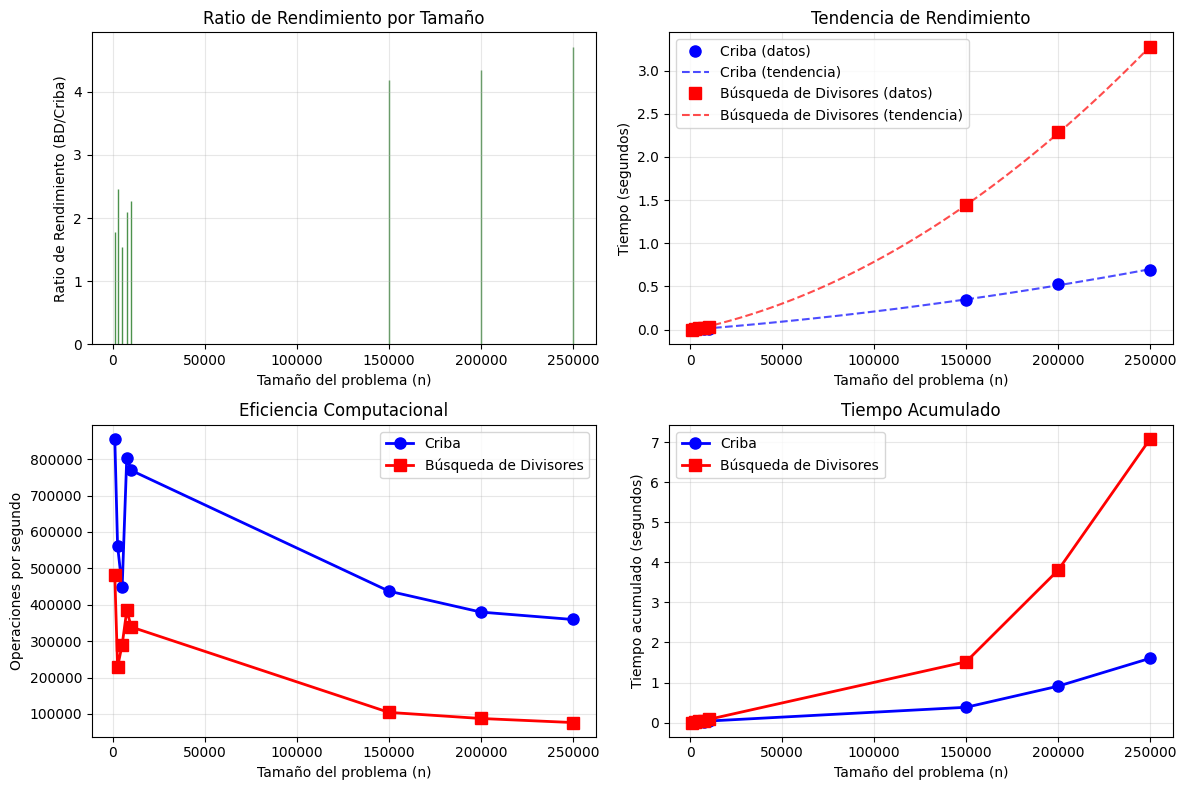

✓ Gráfico 4 guardado: graficos/04_analisis_avanzado.png


In [54]:
# GRÁFICO 4: Análisis de rendimiento relativo
plt.figure(figsize=(12, 8))

# Crear matriz de rendimiento
plt.subplot(2, 2, 1)
performance_ratio = np.array(tiempos_raiz) / np.array(tiempos_criba)
plt.bar(intervalos, performance_ratio, color='green', alpha=0.7, edgecolor='darkgreen')
plt.xlabel('Tamaño del problema (n)')
plt.ylabel('Ratio de Rendimiento (BD/Criba)')
plt.title('Ratio de Rendimiento por Tamaño')
plt.grid(True, alpha=0.3)

# Subplot 2: Tendencia cuadrática
plt.subplot(2, 2, 2)
# Ajuste polinomial para mostrar tendencia
z_criba = np.polyfit(intervalos, tiempos_criba, 2)
p_criba = np.poly1d(z_criba)
z_raiz = np.polyfit(intervalos, tiempos_raiz, 2)
p_raiz = np.poly1d(z_raiz)

x_smooth = np.linspace(min(intervalos), max(intervalos), 100)
plt.plot(intervalos, tiempos_criba, 'o', label='Criba (datos)', color='blue', markersize=8)
plt.plot(x_smooth, p_criba(x_smooth), '--', label='Criba (tendencia)', color='blue', alpha=0.7)
plt.plot(intervalos, tiempos_raiz, 's', label='Búsqueda de Divisores (datos)', color='red', markersize=8)
plt.plot(x_smooth, p_raiz(x_smooth), '--', label='Búsqueda de Divisores (tendencia)', color='red', alpha=0.7)

plt.xlabel('Tamaño del problema (n)')
plt.ylabel('Tiempo (segundos)')
plt.title('Tendencia de Rendimiento')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 3: Eficiencia por operación
plt.subplot(2, 2, 3)
efficiency_criba = [n/t for n, t in zip(intervalos, tiempos_criba)]
efficiency_raiz = [n/t for n, t in zip(intervalos, tiempos_raiz)]

plt.plot(intervalos, efficiency_criba, 'o-', label='Criba', linewidth=2, markersize=8, color='blue')
plt.plot(intervalos, efficiency_raiz, 's-', label='Búsqueda de Divisores', linewidth=2, markersize=8, color='red')
plt.xlabel('Tamaño del problema (n)')
plt.ylabel('Operaciones por segundo')
plt.title('Eficiencia Computacional')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 4: Comparación acumulada
plt.subplot(2, 2, 4)
cumulative_criba = np.cumsum(tiempos_criba)
cumulative_raiz = np.cumsum(tiempos_raiz)

plt.plot(intervalos, cumulative_criba, 'o-', label='Criba', linewidth=2, markersize=8, color='blue')
plt.plot(intervalos, cumulative_raiz, 's-', label='Búsqueda de Divisores', linewidth=2, markersize=8, color='red')
plt.xlabel('Tamaño del problema (n)')
plt.ylabel('Tiempo acumulado (segundos)')
plt.title('Tiempo Acumulado')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('graficos/04_analisis_avanzado.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Gráfico 4 guardado: graficos/04_analisis_avanzado.png")

In [55]:
# Tabla resumen final
print("\n" + "="*80)
print("RESUMEN COMPLETO DE MÉTRICAS")
print("="*80)
print(f"{'n':>8} | {'Criba (s)':>10} | {'Búsqueda Divisores (s)':>18} | {'Eficiencia C':>12} | {'Eficiencia BD':>12}")
print("-"*80)
for i, n in enumerate(intervalos):
    print(f"{n:>8} | {tiempos_criba[i]:>10.4f} | {tiempos_raiz[i]:>18.4f} | {efficiency_criba[i]:>12.0f} | {efficiency_raiz[i]:>12.0f}")

print(f"\nTotal de gráficos generados: 4")
print(f"Directorio de salida: graficos/")
print(f"Eficiencia promedio Criba: {np.mean(efficiency_criba):.0f} ops/s")
print(f"Eficiencia promedio Búsqueda Divisores: {np.mean(efficiency_raiz):.0f} ops/s")


RESUMEN COMPLETO DE MÉTRICAS
       n |  Criba (s) | Búsqueda Divisores (s) | Eficiencia C | Eficiencia BD
--------------------------------------------------------------------------------
    1000 |     0.0012 |             0.0021 |       855515 |       480686
    2500 |     0.0044 |             0.0109 |       562571 |       228858
    5000 |     0.0112 |             0.0172 |       447685 |       290251
    7500 |     0.0093 |             0.0195 |       804616 |       384565
   10000 |     0.0130 |             0.0295 |       769131 |       338873
  150000 |     0.3429 |             1.4385 |       437426 |       104279
  200000 |     0.5264 |             2.2849 |       379914 |        87532
  250000 |     0.6953 |             3.2734 |       359549 |        76372

Total de gráficos generados: 4
Directorio de salida: graficos/
Eficiencia promedio Criba: 577051 ops/s
Eficiencia promedio Búsqueda Divisores: 248927 ops/s
